In [105]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [106]:
RANDOM_STATE = 42
FORECAST_HORIZON = 3  # 3-month ahead forecast

In [107]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "data_for_model_with_validation_flags.csv"
)

In [108]:
df = pd.read_csv(DATA_PATH,parse_dates=["date"])

In [109]:
df.head()

,state,date,month,year,quarter,is_anomaly,is_valid_data,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3,target
0,andaman and nicobar islands,2018-01-01,1,2018,1,0,False,rice,101.71,1220.90,0.00,101.67,100.21,0.10,67.326667,58.224578,407.87
1,andaman and nicobar islands,2018-02-01,2,2018,1,0,False,rice,116.73,13.70,0.00,101.71,101.67,100.21,101.196667,0.854712,414.05
2,andaman and nicobar islands,2018-03-01,3,2018,1,0,False,rice,116.19,7.17,0.00,116.73,101.71,101.67,106.703333,8.683371,429.04
3,andaman and nicobar islands,2018-04-01,4,2018,2,0,True,rice,407.87,12.97,180.92,116.19,116.73,101.71,111.543333,8.520196,436.08
4,andaman and nicobar islands,2018-05-01,5,2018,2,0,True,rice,414.05,40.12,169.25,407.87,116.19,116.73,213.596667,168.245859,423.13


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2052 entries, 0 to 2051
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   state                   2052 non-null   object        
 1   date                    2052 non-null   datetime64[ns]
 2   month                   2052 non-null   int64         
 3   year                    2052 non-null   int64         
 4   quarter                 2052 non-null   int64         
 5   is_anomaly              2052 non-null   int64         
 6   is_valid_data           2052 non-null   bool          
 7   commodity               2052 non-null   object        
 8   total_allocated_qty     2052 non-null   float64       
 9   epos_allocated_qty      2052 non-null   float64       
 10  not_epos_allocated_qty  2052 non-null   float64       
 11  lag_1                   2052 non-null   float64       
 12  lag_2                   2052 non-null   float64 

In [111]:
df["date"].agg(["min", "max"])

min   2017-04-01
max   2021-07-01
Name: date, dtype: datetime64[ns]

In [112]:
df[["is_anomaly", "is_valid_data"]].value_counts()

is_anomaly  is_valid_data
0           True             1730
            False             151
1           True               99
            False              72
Name: count, dtype: int64

In [113]:
# REDEFINING TARGET

In [114]:
df["delta_target"] = df["target"] - df["total_allocated_qty"]
#check: 
df[["total_allocated_qty", "target", "delta_target"]].head()

,total_allocated_qty,target,delta_target
0,101.71,407.87,306.16
1,116.73,414.05,297.32
2,116.19,429.04,312.85
3,407.87,436.08,28.21
4,414.05,423.13,9.08


In [115]:
df["target"].describe().T

count    2.052000e+03
mean     1.167845e+05
std      1.716122e+05
min      0.000000e+00
25%      9.078188e+03
50%      4.137221e+04
75%      1.601889e+05
max      1.457335e+06
Name: target, dtype: float64

In [116]:
df["delta_target"].describe().T

count    2.052000e+03
mean    -3.534920e+03
std      9.310146e+04
min     -1.192809e+06
25%     -1.865123e+03
50%     -1.000000e-01
75%      8.447400e+02
max      1.218260e+06
Name: delta_target, dtype: float64

In [117]:
DROP_COLS = ["month", "quarter"]

df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

In [118]:
df.columns

Index(['state', 'date', 'year', 'is_anomaly', 'is_valid_data', 'commodity',
       'total_allocated_qty', 'epos_allocated_qty', 'not_epos_allocated_qty',
       'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3', 'target',
       'delta_target'],
      dtype='object')

In [119]:
USABLE_MASK = (df["is_anomaly"] == 0) & (df["is_valid_data"] == True)

df_usable = (
    df[USABLE_MASK]
    .sort_values(["state", "commodity", "date"])
    .reset_index(drop=True)
)

In [120]:
df_usable.shape

(1730, 16)

In [121]:
df_usable["date"].agg(["min", "max"])

min   2018-04-01
max   2021-05-01
Name: date, dtype: datetime64[ns]

In [122]:
df_usable["commodity"].value_counts()

commodity
rice     1029
wheat     701
Name: count, dtype: int64

In [123]:
# SPLITTING DATASET BY COMMODITY

In [124]:
# RICE
df_rice = (
    df_usable[df_usable["commodity"] == "rice"]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

In [125]:
# WHEAT
df_wheat = (
    df_usable[df_usable["commodity"] == "wheat"]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

In [126]:
print("Rice shape :", df_rice.shape)
print("Wheat shape:", df_wheat.shape)

Rice shape : (1029, 16)
Wheat shape: (701, 16)


In [127]:
print(df_rice["date"].agg(["min", "max"]))
print(df_wheat["date"].agg(["min", "max"]))

min   2018-04-01
max   2021-05-01
Name: date, dtype: datetime64[ns]
min   2018-04-01
max   2021-05-01
Name: date, dtype: datetime64[ns]


In [128]:
# EXPERIMENT 1 - FORECASTING DURING ROBUST PERIOD

In [129]:
# Experiment 1 date ranges
TRAIN_START_DATE = "2018-04-01"
TRAIN_END_DATE   = "2020-08-01"

VAL_START_DATE   = "2020-12-01"
VAL_END_DATE     = "2021-02-01"

In [130]:
rice_train_df = (
    df_rice[
        (df_rice["date"] >= TRAIN_START_DATE) &
        (df_rice["date"] < TRAIN_END_DATE)    # strict '<' is intentional
    ]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

In [131]:
rice_val_df = (
    df_rice[
        (df_rice["date"] >= VAL_START_DATE) &
        (df_rice["date"] <= VAL_END_DATE)
    ]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

In [132]:
latest_train_target_date = (
    rice_train_df["date"] + pd.DateOffset(months=FORECAST_HORIZON)
).max()

earliest_val_feature_date = rice_val_df["date"].min()

print("Latest train target date :", latest_train_target_date)
print("Earliest val feature date:", earliest_val_feature_date)

Latest train target date : 2020-10-01 00:00:00
Earliest val feature date: 2020-12-01 00:00:00


In [133]:
print("Rice — Train rows:", rice_train_df.shape[0])
print("Rice — Val rows  :", rice_val_df.shape[0])

Rice — Train rows: 819
Rice — Val rows  : 91


In [134]:
print("Rice — Train range:", rice_train_df["date"].min(), "→", rice_train_df["date"].max())
print("Rice — Val range  :", rice_val_df["date"].min(), "→", rice_val_df["date"].max())

Rice — Train range: 2018-04-01 00:00:00 → 2020-07-01 00:00:00
Rice — Val range  : 2020-12-01 00:00:00 → 2021-02-01 00:00:00


In [135]:
print("Train states:", rice_train_df["state"].nunique())
print("Val states  :", rice_val_df["state"].nunique())

Train states: 30
Val states  : 31


In [136]:
TARGET_COL = "delta_target"

In [137]:
NUMERIC_FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_3",
    "rolling_std_3",
]

CATEGORICAL_FEATURES = [
    "state"
]

In [138]:
set(NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]).issubset(rice_train_df.columns)

True

In [139]:
X_train = rice_train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = rice_train_df[TARGET_COL]

X_val = rice_val_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = rice_val_df[TARGET_COL]

In [140]:
X_train.shape, X_val.shape

((819, 6), (91, 6))

In [141]:
# BUILDING PREPROCESSING FEATURES

In [142]:
# Numeric columns
numeric_transformer = Pipeline(
    steps=[
        ("passthrough", "passthrough")
    ]
)

In [143]:
# Categorical columns
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [144]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ],
    remainder="drop"
)

In [145]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [146]:
# Build Pipeline + Train
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [147]:
delta_val_pred = rf_pipeline.predict(X_val)

In [148]:
# Reconstruct absolute value predictions
level_val_pred = (
    rice_val_df["total_allocated_qty"].values + delta_val_pred
)
level_val_true = rice_val_df["target"].values

In [149]:
mae = mean_absolute_error(level_val_true, level_val_pred)
mse = mean_squared_error(level_val_true, level_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(level_val_true, level_val_pred)
print(f"[Rice | Delta RF] Validation MAE  : {mae:,.2f}")
print(f"[Rice | Delta RF] Validation RMSE : {rmse:,.2f}")
print(f"[Rice | Delta RF] Validation R²   : {r2:.3f}")

[Rice | Delta RF] Validation MAE  : 11,101.48
[Rice | Delta RF] Validation RMSE : 24,235.61
[Rice | Delta RF] Validation R²   : 0.940


In [150]:
baseline_level_pred = rice_val_df["total_allocated_qty"].values
baseline_mae = mean_absolute_error(level_val_true, baseline_level_pred)
baseline_rmse = np.sqrt(mean_squared_error(level_val_true, baseline_level_pred))

print("[Rice | Naive Delta] MAE :", baseline_mae)
print("[Rice | Naive Delta] RMSE:", baseline_rmse)

[Rice | Naive Delta] MAE : 8415.64934065934
[Rice | Naive Delta] RMSE: 21815.28705342723


In [151]:
# VISUALISE THE Actual vs Predicted for Rice

In [152]:
# Full actuals (train + validation)
actuals_df = pd.concat(
    [
        rice_train_df[["date", "target"]],
        rice_val_df[["date", "target"]],
    ],
    ignore_index=True
)

In [153]:
actuals_monthly = (
    actuals_df
    .groupby("date")["target"]
    .sum()
    .reset_index()
)

In [154]:
# Validation predictions
val_preds_df = rice_val_df[["date"]].copy()
val_preds_df["predicted"] = level_val_pred
# aggregate predictions to national level
val_preds_monthly = (
    val_preds_df
    .groupby("date")["predicted"]
    .sum()
    .reset_index()
)

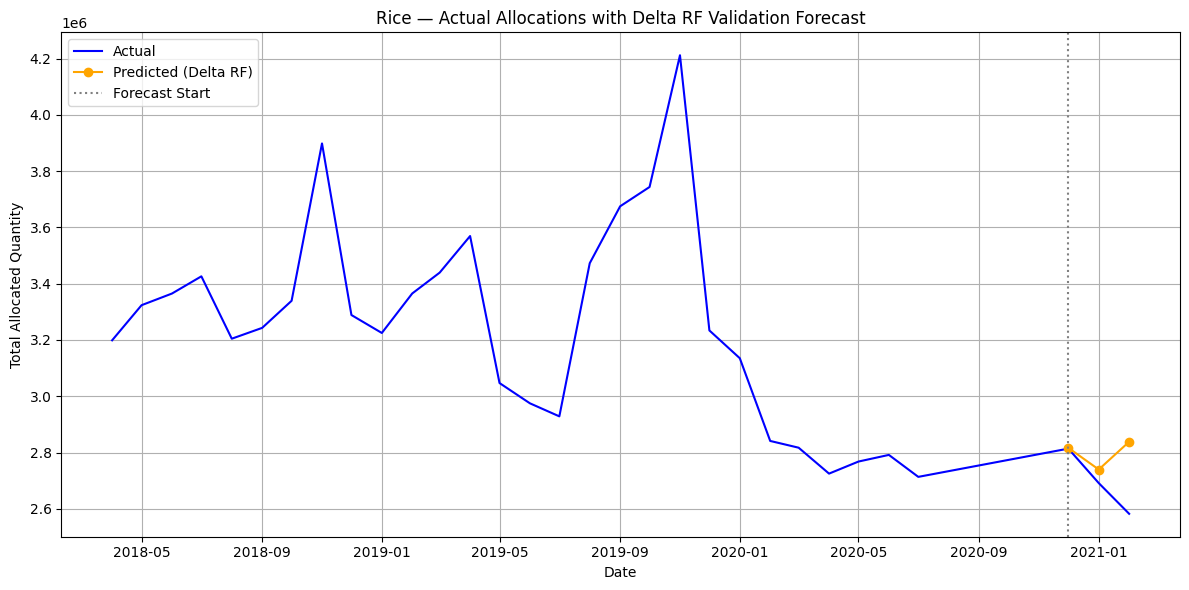

In [155]:
plt.figure(figsize=(12, 6))

# Actuals: full timeline
plt.plot(
    actuals_monthly["date"],
    actuals_monthly["target"],
    label="Actual",
    color="blue"
)

# Predictions: validation only
plt.plot(
    val_preds_monthly["date"],
    val_preds_monthly["predicted"],
    label="Predicted (Delta RF)",
    color="orange",
    marker="o"
)

# Vertical line to indicate forecast start
plt.axvline(
    x=val_preds_monthly["date"].min(),
    color="grey",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Rice — Actual Allocations with Delta RF Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Total Allocated Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [180]:
# EXPERIMENT 2
# Experiment 2 date ranges
TRAIN_START_DATE = "2018-04-01"
TRAIN_END_DATE   = "2020-11-01"

VAL_START_DATE   = "2021-03-01"
VAL_END_DATE     = "2021-05-01"


In [181]:
rice_train_df = (
    df_rice[
        (df_rice["date"] >= TRAIN_START_DATE) &
        (df_rice["date"] < TRAIN_END_DATE)   # strict <
    ]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

rice_val_df = (
    df_rice[
        (df_rice["date"] >= VAL_START_DATE) &
        (df_rice["date"] <= VAL_END_DATE)
    ]
    .sort_values(["state", "date"])
    .reset_index(drop=True)
)

In [182]:
latest_train_target_date = (
    rice_train_df["date"] + pd.DateOffset(months=FORECAST_HORIZON)
).max()

earliest_val_feature_date = rice_val_df["date"].min()

print("Latest train target date :", latest_train_target_date)
print("Earliest val feature date:", earliest_val_feature_date)

Latest train target date : 2020-10-01 00:00:00
Earliest val feature date: 2021-03-01 00:00:00


In [183]:
X_train = rice_train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = rice_train_df[TARGET_COL]

X_val = rice_val_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_val = rice_val_df[TARGET_COL]

In [184]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [185]:
delta_val_pred = rf_pipeline.predict(X_val)

level_val_pred = (
    rice_val_df["total_allocated_qty"].values + delta_val_pred
)

level_val_true = rice_val_df["target"].values

In [186]:
mae = mean_absolute_error(level_val_true, level_val_pred)
rmse = np.sqrt(mean_squared_error(level_val_true, level_val_pred))
r2 = r2_score(level_val_true, level_val_pred)

print(f"[Rice | Delta RF | Exp2] MAE  : {mae:,.2f}")
print(f"[Rice | Delta RF | Exp2] RMSE : {rmse:,.2f}")
print(f"[Rice | Delta RF | Exp2] R²   : {r2:.3f}")

[Rice | Delta RF | Exp2] MAE  : 21,130.36
[Rice | Delta RF | Exp2] RMSE : 37,005.96
[Rice | Delta RF | Exp2] R²   : 0.842


In [187]:
baseline_level_pred = rice_val_df["total_allocated_qty"].values

baseline_mae = mean_absolute_error(level_val_true, baseline_level_pred)
baseline_rmse = np.sqrt(mean_squared_error(level_val_true, baseline_level_pred))

print("[Rice | Naive Delta | Exp2] MAE :", baseline_mae)
print("[Rice | Naive Delta | Exp2] RMSE:", baseline_rmse)


[Rice | Naive Delta | Exp2] MAE : 19247.392921348317
[Rice | Naive Delta | Exp2] RMSE: 35974.85370310076


In [192]:
train_mean = rice_train_df["target"].mean()
train_std = rice_train_df["target"].std()

In [193]:
nmae = mae / train_mean
print(f"Normalized MAE (nMAE) : {nmae:.3f} ({nmae*100:.1f}%)")
nrmse = rmse / train_std
print(f"Normalized RMSE (nRMSE) : {nrmse:.3f}")
nrmse_mean = rmse / train_mean
print(f"RMSE / Mean : {nrmse_mean:.3f} ({nrmse_mean*100:.1f}%)")


Normalized MAE (nMAE) : 0.190 (19.0%)
Normalized RMSE (nRMSE) : 0.245
RMSE / Mean : 0.333 (33.3%)


In [188]:
# Full actuals (train + validation)
actuals_df = pd.concat(
    [
        rice_train_df[["date", "target"]],
        rice_val_df[["date", "target"]],
    ],
    ignore_index=True
)

In [189]:
actuals_monthly = (
    actuals_df
    .groupby("date")["target"]
    .sum()
    .reset_index()
)

In [190]:
# Validation predictions
val_preds_df = rice_val_df[["date"]].copy()
val_preds_df["predicted"] = level_val_pred
# aggregate predictions to national level
val_preds_monthly = (
    val_preds_df
    .groupby("date")["predicted"]
    .sum()
    .reset_index()
)

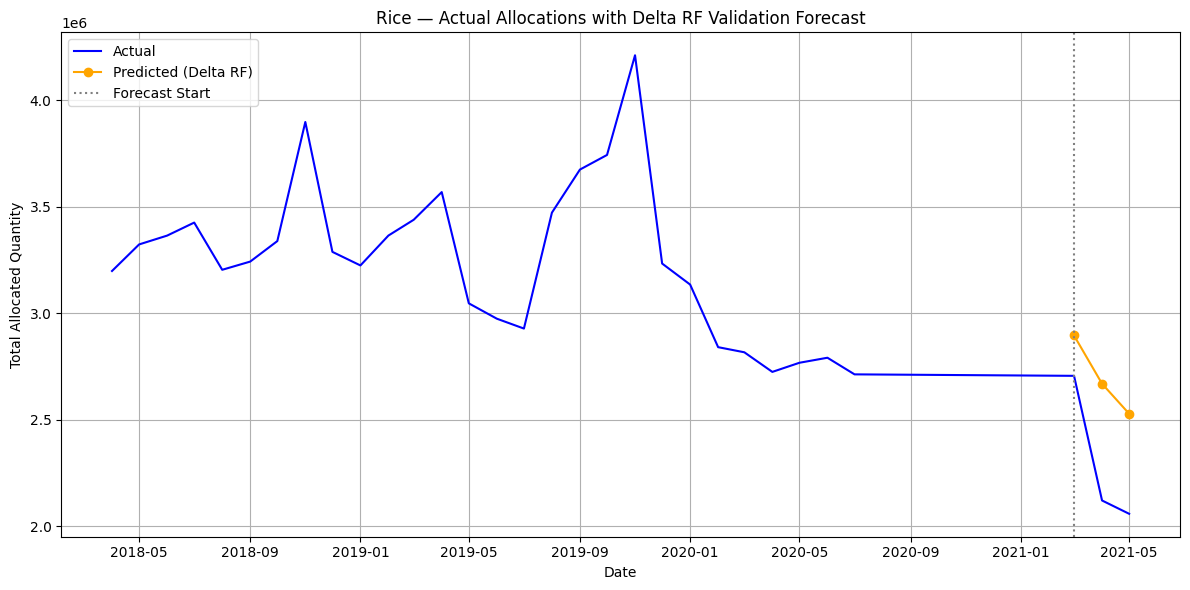

In [191]:
plt.figure(figsize=(12, 6))

# Actuals: full timeline
plt.plot(
    actuals_monthly["date"],
    actuals_monthly["target"],
    label="Actual",
    color="blue"
)

# Predictions: validation only
plt.plot(
    val_preds_monthly["date"],
    val_preds_monthly["predicted"],
    label="Predicted (Delta RF)",
    color="orange",
    marker="o"
)

# Vertical line to indicate forecast start
plt.axvline(
    x=val_preds_monthly["date"].min(),
    color="grey",
    linestyle=":",
    label="Forecast Start"
)

plt.title("Rice — Actual Allocations with Delta RF Validation Forecast")
plt.xlabel("Date")
plt.ylabel("Total Allocated Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
